# H2 – Hybrid Recommender: Explainable AI (XAI) Pipeline

**Purpose:** Explain individual recommendations from the trained Hybrid Recommender using:
- Score breakdown (CF + Content contributions)
- Collaborative Filtering narrative (similar users)
- Content-Based genre attribution
- SHAP KernelExplainer (content features)
- LIME TabularExplainer (content features)

**Design constraints:**
- Training notebooks are NOT modified.
- The hybrid model runs exactly ONCE per request.
- JSON input simulates a production API call.
- `utils_hybrid_xai.py` must live in the same directory as this notebook.

## 0 · Environment Setup

In [1]:
# Install XAI dependencies if needed (run once)
!pip install shap lime --quiet
!pip install jinja2 --quiet

import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

print("shap:", shap.__version__)
print("lime: OK (", lime.__file__, ")")

/opt/miniconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


shap: 0.49.1
lime: OK ( /opt/miniconda3/lib/python3.12/site-packages/lime/__init__.py )


In [2]:
import sys
import json
import pickle
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR   = Path('/Users/moustafa/new_Xplaina/XplainaV301/HybridModel')
PROJECT_ROOT   = Path('/Users/moustafa/new_Xplaina/XplainaV301')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR    = NOTEBOOK_DIR / 'results'
FIGURES_DIR    = NOTEBOOK_DIR / 'figures'

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Find CF pickle files ───────────────────────────────────────────────────────
print("Searching for .pkl files...")
picks = glob.glob(str(PROJECT_ROOT / '**' / '*.pkl'), recursive=True)
if picks:
    for p in picks:
        print(" found:", p)
    MODELS_DIR = Path(picks[0]).parent
else:
    print(" No .pkl files found — CF models will be built inline.")
    MODELS_DIR = PROJECT_ROOT / 'models'

# ── Sanity check ──────────────────────────────────────────────────────────────
print()
print("PROJECT_ROOT  :", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("MODELS_DIR    :", MODELS_DIR)
print("ratings exists:", (DATA_PROCESSED / 'ratings_full_with_predictions.csv').exists())
print("courses exists :", (DATA_PROCESSED / 'final_courses.csv').exists())
print("models dir    :", MODELS_DIR.exists())

# ── Imports ───────────────────────────────────────────────────────────────────
if str(NOTEBOOK_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))


# ── Force reload XAI module so latest file is always used ────────────────
import importlib
if 'utils_hybrid_xai' in sys.modules:
    importlib.reload(sys.modules['utils_hybrid_xai'])
import utils_hybrid_xai as xai
from utils_hybrid import (
    load_hybrid_data, load_cf_models,
    build_content_similarity, train_test_split_by_user,
    build_user_item_matrix, build_cf_predictions,
    GENRE_COLS,
)

print('Imports OK')

Searching for .pkl files...
 found: /Users/moustafa/new_Xplaina/XplainaV301/models/06_pred_item_knn.pkl
 found: /Users/moustafa/new_Xplaina/XplainaV301/models/06_pred_user_knn.pkl

PROJECT_ROOT  : /Users/moustafa/new_Xplaina/XplainaV301
DATA_PROCESSED: /Users/moustafa/new_Xplaina/XplainaV301/data/processed
MODELS_DIR    : /Users/moustafa/new_Xplaina/XplainaV301/models
ratings exists: True
courses exists : True
models dir    : True
Imports OK


## 1 · Load Pre-Trained Artefacts

Loads data and CF models saved by H1. If no pickles are found, CF predictions
are built inline and saved to `models/` so subsequent runs skip this step.

In [3]:
# ── Ratings & courses ─────────────────────────────────────────────────────────
ratings_full, courses_df = load_hybrid_data(DATA_RAW, DATA_PROCESSED)

# ── Train/test split (must match H1 parameters exactly) ──────────────────────
train_df, test_df = train_test_split_by_user(
    ratings_full, min_user_ratings=5, test_size=0.2, seed=42
)

# ── Content similarity matrix ─────────────────────────────────────────────────
sim_df = build_content_similarity(courses_df, method='tfidf')

# ── CF predictions: load pickles if available, otherwise build inline ─────────
if MODELS_DIR.exists() and (MODELS_DIR / '06_pred_user_knn.pkl').exists():
    pred_user_knn, pred_item_knn = load_cf_models(MODELS_DIR)
else:
    print("Building CF predictions inline (this may take ~1 min)...")
    train_utility = build_user_item_matrix(train_df)
    pred_user_knn, pred_item_knn = build_cf_predictions(train_utility, k=20)
    # Save so next run is instant
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    with open(MODELS_DIR / '06_pred_user_knn.pkl', 'wb') as f:
        pickle.dump(pred_user_knn, f)
    with open(MODELS_DIR / '06_pred_item_knn.pkl', 'wb') as f:
        pickle.dump(pred_item_knn, f)
    print(f"CF models saved → {MODELS_DIR}")

cf_predictions = pred_user_knn

# ── Alpha (CF weight) – set to your optimal value from H1 alpha sweep ─────────
ALPHA = 0.5

print()
print(f"train_df     : {len(train_df):,} rows")
print(f"courses_df   : {len(courses_df):,} courses")
print(f"sim_df       : {sim_df.shape}")
print(f"CF users     : {len(cf_predictions):,}")
print(f"Alpha        : {ALPHA}")

[utils_hybrid] Loaded CF models from /Users/moustafa/new_Xplaina/XplainaV301/models

train_df     : 189,876 rows
courses_df   : 307 courses
sim_df       : (307, 307)
CF users     : 34,082
Alpha        : 0.5


## 2 · JSON Request – Simulate Production Input
Change `user_id` / `item_id` to any valid values from your dataset.

In [4]:
# ── Pick a well-rated user (strong CF signal) and a sample item ──────────
# Users with many ratings have richer CF + content explanations.
# We pick the user with the most training ratings automatically.
user_counts = train_df.groupby('user').size().sort_values(ascending=False)
SAMPLE_USER = int(user_counts.index[0])
SAMPLE_ITEM = sim_df.columns[0]   # first course in sim matrix

print(f'Selected user : {SAMPLE_USER}  ({user_counts[SAMPLE_USER]} ratings in train set)')
print(f'Selected item : {SAMPLE_ITEM}')

# ── Single-item explanation request ──────────────────────────────────────────
request_single = {
    "user_id":      SAMPLE_USER,
    "item_id":      SAMPLE_ITEM,
    "alpha":        ALPHA,
    "include_shap": True,
    "include_lime": True,
}

# ── Batch (top-N) request ──────────────────────────────────────────────────
request_batch = {
    "user_id":      SAMPLE_USER,
    "item_id":      None,
    "alpha":        ALPHA,
    "top_n":        10,
    "include_shap": False,
    "include_lime": True,
}

print('Requests defined.')
print(json.dumps(request_single, indent=2))


Selected user : 2  (49 ratings in train set)
Selected item : ML0201EN
Requests defined.
{
  "user_id": 2,
  "item_id": "ML0201EN",
  "alpha": 0.5,
  "include_shap": true,
  "include_lime": true
}


## 3 · Run XAI Pipeline – Single Item

In [5]:
response = xai.handle_json_request(
    request=request_single,
    train_df=train_df,
    cf_predictions=cf_predictions,
    sim_df=sim_df,
    courses_df=courses_df,
)

exp = response['explanations'][0]
print(response['summary'])

RECOMMENDATION EXPLANATION
  User  : 2
  Item  : ML0201EN

── SCORE BREAKDOWN ──────────────────────────────────────
  Hybrid Score    : 0.0327
  CF Score        : 0.0000  × α=0.5  → contribution 0.0000
  Content Score   : 0.0654  × (1-α)=0.5  → contribution 0.0327

── COLLABORATIVE FILTERING EXPLANATION ──────────────────
  Recommended because 5 users with strong taste overlap rated this course (avg rating: 3.0/3.0). Most similar user gave it 3.0.
  Top similar users who rated this course:
    • user 297331.0  rating=3.0  similarity=1.0
    • user 359925.0  rating=3.0  similarity=1.0
    • user 413305.0  rating=3.0  similarity=1.0

── CONTENT-BASED EXPLANATION ────────────────────────────
  Matched because of shared topics: BackendDev, FrontendDev. Content similarity score: 0.012.
  Matching genres (target ∩ user history):
    • BackendDev         ███ 0.1633
    • FrontendDev         0.0204

── SHAP FEATURE IMPORTANCE (content) ───────────────────
  Base value : 0.3689
  Prediction : 

### 3.1 Score Breakdown

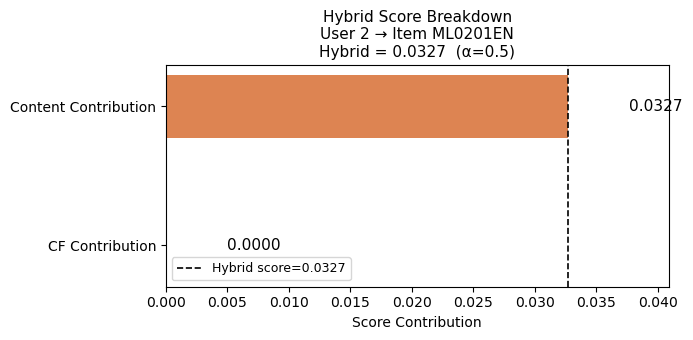

In [6]:
scores = exp['scores']

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ['CF Contribution', 'Content Contribution']
values = [scores['cf_contribution'], scores['content_contribution']]
colors = ['#4C72B0', '#DD8452']

bars = ax.barh(labels, values, color=colors, height=0.45)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11)

ax.set_xlim(0, max(values) * 1.25)
ax.set_xlabel('Score Contribution')
ax.set_title(
    f'Hybrid Score Breakdown\n'
    f'User {exp["user"]} → Item {exp["item"]}\n'
    f'Hybrid = {scores["hybrid_score"]:.4f}  (α={scores["alpha"]})',
    fontsize=11
)
ax.axvline(scores['hybrid_score'], color='black', linestyle='--',
           linewidth=1.2, label=f'Hybrid score={scores["hybrid_score"]:.4f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_score_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Collaborative Filtering Explanation

── CF Explanation ──────────────────────────────────────
CF score  : 0.0
Narrative : Recommended because 5 users with strong taste overlap rated this course (avg rating: 3.0/3.0). Most similar user gave it 3.0.

Similar users who rated this item:


,user,rating,similarity
0,297331.0,3.0,1.0
1,359925.0,3.0,1.0
2,413305.0,3.0,1.0
3,512106.0,3.0,1.0
4,554499.0,3.0,1.0


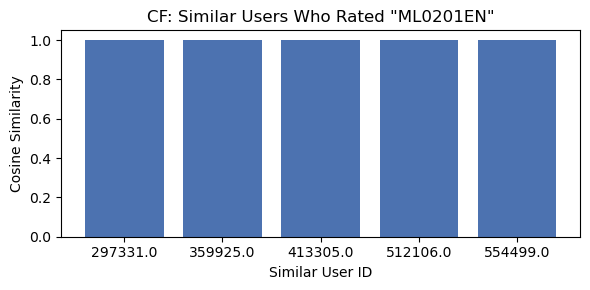

In [7]:
cf_exp = exp['cf_explanation']

print('── CF Explanation ──────────────────────────────────────')
print(f"CF score  : {cf_exp['cf_score']}")
print(f"Narrative : {cf_exp['narrative']}")
print()

similar_users = cf_exp.get('similar_users_who_rated', [])
if similar_users:
    su_df = pd.DataFrame(similar_users)
    print('Similar users who rated this item:')
    display(su_df)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar([str(u['user']) for u in similar_users],
           [u['similarity'] for u in similar_users],
           color='#4C72B0')
    ax.set_xlabel('Similar User ID')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'CF: Similar Users Who Rated "{exp["item"]}"')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'xai_cf_similar_users.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No similar users found (possible cold-start).')

### 3.3 Content-Based Explanation

── Content Explanation ─────────────────────────────────
Content score : 0.0117
Narrative     : Matched because of shared topics: BackendDev, FrontendDev. Content similarity score: 0.012.


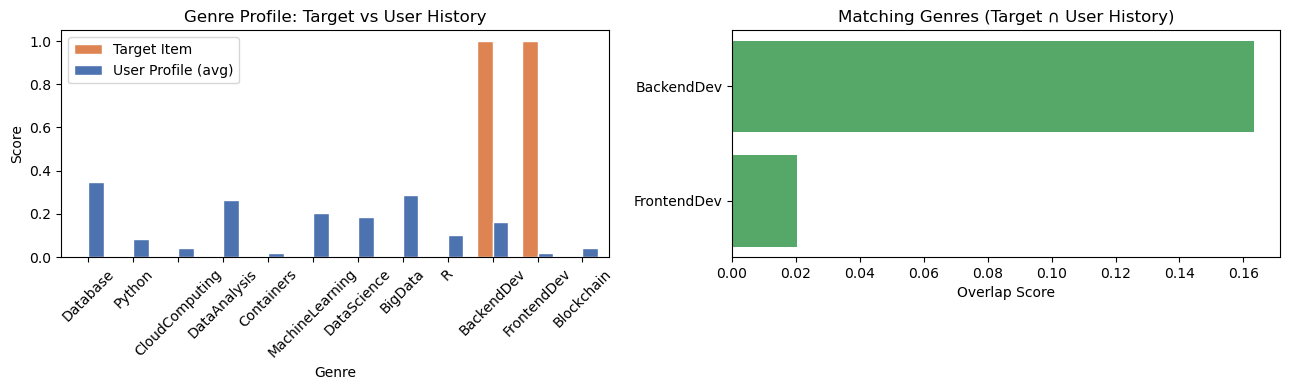


Top similar courses in user history:
  • WA0101EN  similarity=0.1599
  • LB0101ENv1  similarity=0.0971
  • TMP0105EN  similarity=0.0844


In [8]:
con_exp = exp['content_explanation']

print('── Content Explanation ─────────────────────────────────')
print(f"Content score : {con_exp['content_score']}")
print(f"Narrative     : {con_exp['narrative']}")

target_g = con_exp['target_item_genres']      # all genres, 0 or 1
user_g   = con_exp['user_genre_profile']       # avg per genre
matching = con_exp['matching_genre_scores']    # only overlapping genres

# FIX: use ALL genres so both bars always render
genre_df = pd.DataFrame({
    'Target Item': pd.Series(target_g),
    'User Profile (avg)': pd.Series(user_g),
})
# Keep only genres that have at least some signal in either column
genre_df = genre_df[(genre_df['Target Item'] > 0) | (genre_df['User Profile (avg)'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if not genre_df.empty:
    genre_df.plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'],
                  edgecolor='white', width=0.7)
    axes[0].set_title('Genre Profile: Target vs User History')
    axes[0].set_xlabel('Genre')
    axes[0].set_ylabel('Score')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No genre data available', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Genre Profile')

if matching:
    axes[1].barh(list(matching.keys()), list(matching.values()), color='#55A868')
    axes[1].set_xlabel('Overlap Score')
    axes[1].set_title('Matching Genres (Target ∩ User History)')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No genre overlap', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Matching Genres')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_content_genres.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop similar courses in user history:')
for c in con_exp.get('top_similar_courses_in_history', []):
    print(f"  • {c['item']}  similarity={c['similarity']}")


### 3.4 SHAP Explanation (Content Features)

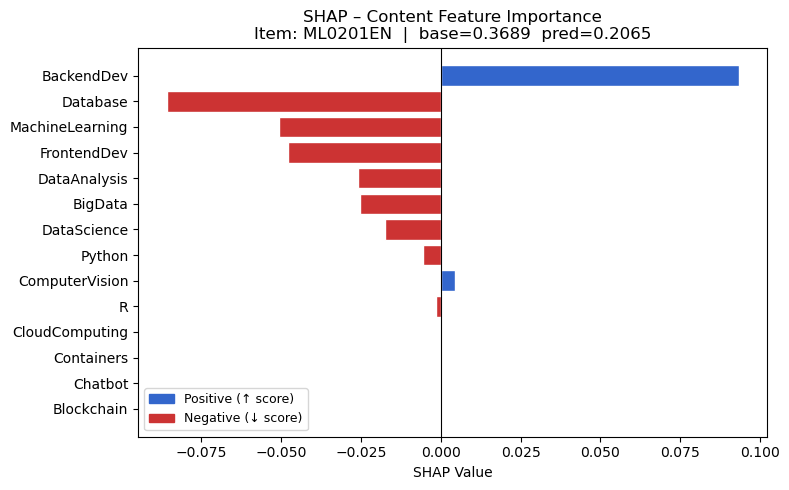

In [9]:
shap_exp = exp.get('shap_explanation', {})

if shap_exp and 'error' not in shap_exp:
    plot_data = shap_exp['plot_data']
    features  = [d['feature'] for d in plot_data]
    shap_vals = [d['shap'] for d in plot_data]
    colors_s  = ['#CC3333' if v < 0 else '#3366CC' for v in shap_vals]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(features, shap_vals, color=colors_s, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP Value')
    ax.set_title(
        f'SHAP – Content Feature Importance\n'
        f'Item: {exp["item"]}  |  base={shap_exp["base_value"]:.4f}  '
        f'pred={shap_exp["prediction"]:.4f}'
    )
    ax.invert_yaxis()
    pos_patch = mpatches.Patch(color='#3366CC', label='Positive (↑ score)')
    neg_patch = mpatches.Patch(color='#CC3333', label='Negative (↓ score)')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'xai_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
elif shap_exp and 'error' in shap_exp:
    print(f'SHAP skipped: {shap_exp["error"]}')
else:
    print('SHAP was not requested (include_shap=False).')

### 3.5 LIME Explanation (Content Features)

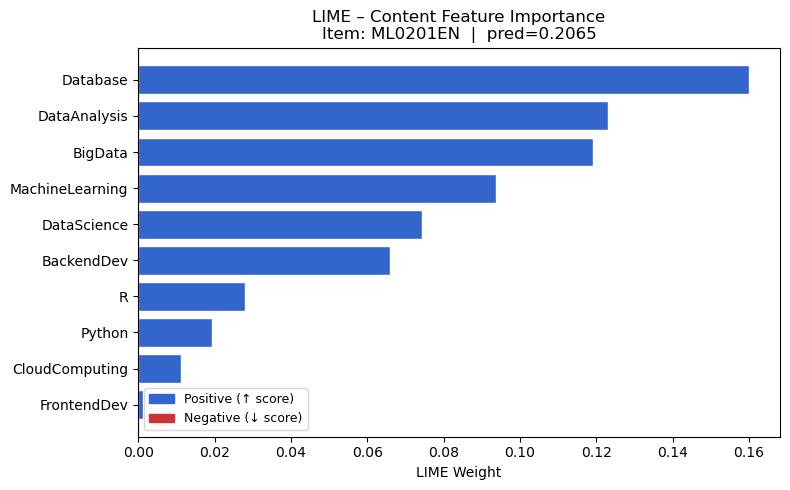

In [10]:
lime_exp = exp.get('lime_explanation', {})

if lime_exp and 'error' not in lime_exp:
    plot_data = lime_exp['plot_data']
    features  = [d['feature'] for d in plot_data]
    weights   = [d['weight'] for d in plot_data]
    colors_l  = ['#CC3333' if w < 0 else '#3366CC' for w in weights]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(features, weights, color=colors_l, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Weight')
    ax.set_title(
        f'LIME – Content Feature Importance\n'
        f'Item: {exp["item"]}  |  pred={lime_exp["prediction"]:.4f}'
    )
    ax.invert_yaxis()
    pos_patch = mpatches.Patch(color='#3366CC', label='Positive (↑ score)')
    neg_patch = mpatches.Patch(color='#CC3333', label='Negative (↓ score)')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'xai_lime_weights.png', dpi=150, bbox_inches='tight')
    plt.show()
elif lime_exp and 'error' in lime_exp:
    print(f'LIME skipped: {lime_exp["error"]}')
else:
    print('LIME was not requested (include_lime=False).')

### 3.6 Full Text Report

In [11]:
report = xai.format_explanation_report(exp)
print(report)

report_path = RESULTS_DIR / f"xai_report_user{exp['user']}_item{exp['item']}.txt"
report_path.write_text(report)
print(f'\nReport saved → {report_path}')

RECOMMENDATION EXPLANATION
  User  : 2
  Item  : ML0201EN

── SCORE BREAKDOWN ──────────────────────────────────────
  Hybrid Score    : 0.0327
  CF Score        : 0.0000  × α=0.5  → contribution 0.0000
  Content Score   : 0.0654  × (1-α)=0.5  → contribution 0.0327

── COLLABORATIVE FILTERING EXPLANATION ──────────────────
  Recommended because 5 users with strong taste overlap rated this course (avg rating: 3.0/3.0). Most similar user gave it 3.0.
  Top similar users who rated this course:
    • user 297331.0  rating=3.0  similarity=1.0
    • user 359925.0  rating=3.0  similarity=1.0
    • user 413305.0  rating=3.0  similarity=1.0

── CONTENT-BASED EXPLANATION ────────────────────────────
  Matched because of shared topics: BackendDev, FrontendDev. Content similarity score: 0.012.
  Matching genres (target ∩ user history):
    • BackendDev         ███ 0.1633
    • FrontendDev         0.0204

── SHAP FEATURE IMPORTANCE (content) ───────────────────
  Base value : 0.3689
  Prediction : 

---
## 4 · Batch Explanation – Top-N Recommendations

In [12]:
batch_response = xai.handle_json_request(
    request=request_batch,
    train_df=train_df,
    cf_predictions=cf_predictions,
    sim_df=sim_df,
    courses_df=courses_df,
)

print(batch_response['summary'])
print(f"Explanations returned: {len(batch_response['explanations'])}")

Top-10 recommendations for user 2 (α=0.5, CF weight=50%, content weight=50%).
Explanations returned: 10


In [13]:
# Summary DataFrame
rows = []
for e in batch_response['explanations']:
    sc = e['scores']
    ce = e['content_explanation']
    title_row = courses_df[courses_df['COURSE_ID'] == e['item']]
    title = title_row['TITLE'].iloc[0] if not title_row.empty else e['item']
    rows.append({
        'COURSE_ID':       e['item'],
        'Title':           title[:50],
        'Hybrid Score':    sc['hybrid_score'],
        'CF Score':        sc['cf_score'],
        'Content Score':   sc['content_score'],
        'CF Contrib':      sc['cf_contribution'],
        'Content Contrib': sc['content_contribution'],
        'Top Genres':      ', '.join(list(ce['matching_genre_scores'].keys())[:3]),
    })

batch_df = pd.DataFrame(rows)
try:
    import jinja2
    display(batch_df.style.background_gradient(subset=['Hybrid Score'], cmap='YlGn'))
except AttributeError:
    display(batch_df)


,COURSE_ID,Title,Hybrid Score,CF Score,Content Score,CF Contrib,Content Contrib,Top Genres
0,BD0111EN,hadoop 101,0.9554,1.0,0.9108,0.5,0.4554,"Database, BigData"
1,TA0105EN,text analytics 101,0.8635,1.0,0.7270,0.5,0.3635,MachineLearning
2,ML0115EN,deep learning 101,0.8603,1.0,0.7206,0.5,0.3603,MachineLearning
3,BD0212EN,spark fundamentals ii,0.8223,1.0,0.6447,0.5,0.3223,"Database, BigData, DataAnalysis"
4,DB0151EN,nosql and dbaas 101,0.7894,1.0,0.5789,0.5,0.2894,"Database, BigData"
5,RP0101EN,r for data science,0.7650,1.0,0.5300,0.5,0.2650,"DataScience, R"
6,ML0101EN,machine learning with python,0.7559,1.0,0.5118,0.5,0.2559,"MachineLearning, DataScience, Python"
7,DS0101EN,introduction to data science,0.7395,1.0,0.4791,0.5,0.2395,DataScience
8,ML0101ENv3,machine learning with python,0.7090,1.0,0.4180,0.5,0.2090,"MachineLearning, Python"
9,BD0115EN,mapreduce and yarn,0.6635,1.0,0.3269,0.5,0.1635,"Database, BigData"


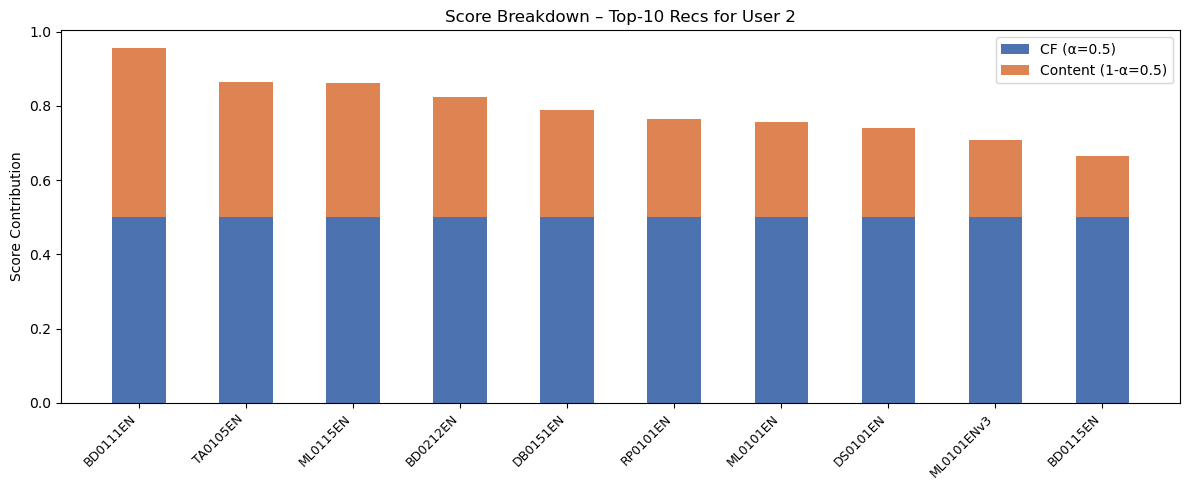

In [14]:
# Stacked bar: CF vs Content contribution per recommended ite
items_short = [r['COURSE_ID'][:20] for r in rows]
cf_c  = [r['CF Contrib']      for r in rows]
con_c = [r['Content Contrib'] for r in rows]

x = np.arange(len(items_short))
w = 0.5

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, cf_c,  w, label=f'CF (α={ALPHA})', color='#4C72B0')
ax.bar(x, con_c, w, bottom=cf_c, label=f'Content (1-α={(1-ALPHA)})', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(items_short, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score Contribution')
ax.set_title(f'Score Breakdown – Top-{len(rows)} Recs for User {SAMPLE_USER}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_batch_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 · LIME Explainer Reuse (Efficiency)
Build the LIME explainer once and pass it into each call to avoid re-fitting.

In [15]:
try:
    lime_exp_obj, feat_df, genre_names = xai.build_lime_explainer(courses_df)
    print(f'LIME explainer ready. Feature space: {genre_names}')

    lime_result = xai.lime_content_explanation(
        user=SAMPLE_USER,
        item=SAMPLE_ITEM,
        train_df=train_df,
        courses_df=courses_df,
        lime_explainer=lime_exp_obj,
        num_features=10,
    )
    print('LIME weights:', lime_result.get('lime_weights', {}))
except ImportError as e:
    print(f'LIME not available: {e}')

LIME explainer ready. Feature space: ['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision', 'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain']
LIME weights: {'Database': 0.160139, 'DataAnalysis': 0.123033, 'BigData': 0.119163, 'MachineLearning': 0.093784, 'DataScience': 0.074371, 'BackendDev': 0.06593, 'R': 0.028105, 'Python': 0.019383, 'CloudComputing': 0.011286, 'FrontendDev': 0.001151}


---
## 6 · Save Explanation Results to JSON

In [16]:
import math

def _json_safe(obj):
    """Recursively convert numpy types and NaN to JSON-serialisable types."""
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return None if math.isnan(float(obj)) else float(obj)
    if isinstance(obj, (np.ndarray, pd.Series, pd.Index)):
        return _json_safe(obj.tolist())
    if isinstance(obj, set):
        return list(obj)
    return obj

output_path = RESULTS_DIR / f'xai_single_user{SAMPLE_USER}_{SAMPLE_ITEM}.json'
with open(output_path, 'w') as f:
    json.dump(_json_safe(response), f, indent=2)
print(f'Saved → {output_path}')

batch_output_path = RESULTS_DIR / f'xai_batch_user{SAMPLE_USER}.json'
with open(batch_output_path, 'w') as f:
    json.dump(_json_safe(batch_response), f, indent=2)
print(f'Saved → {batch_output_path}')

Saved → /Users/moustafa/new_Xplaina/XplainaV301/HybridModel/results/xai_single_user2_ML0201EN.json
Saved → /Users/moustafa/new_Xplaina/XplainaV301/HybridModel/results/xai_batch_user2.json


---
## Summary

| Component | Method | Output |
|-----------|--------|--------|
| Score breakdown | Hybrid formula | CF + Content contributions |
| CF explanation | Similar-user cosine similarity | Top similar users & their ratings |
| Content explanation | Genre overlap analysis | Matching genre scores |
| SHAP | KernelExplainer on genre dot-product | Per-genre SHAP values |
| LIME | TabularExplainer on genre features | Per-genre LIME weights |

**Next steps:**
- Integrate `handle_json_request()` behind a REST endpoint (FastAPI / Flask).
- Swap in your optimal `ALPHA` from the H1 alpha sweep.
- Add a front-end component that renders the breakdown bar chart per recommendation.